### 1. Setup

In [1]:
import torchxrayvision as xrv
import torch
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torchvision.utils import save_image
from pathlib import Path
from dataclasses import asdict
import sys
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Add utils and models to path
project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

from preprocessing import Preprocessing
from cvae_cnn import CVAE
from counterfactual_evaluation import (
    fid_metric_calculation,
    ssim_metric_calculation,
    save_cvae_change_heatmap_sweep,
    EvaluationResult,
    write_metrics_json,
)

### 2. Hyperparameters

In [2]:
img_channels = 2
img_size = 256
latent_dim = 64
base_channels = 32
dropout = 0.05
num_classes = 2
metadata_dim = 2
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
add_lung_mask_channel = True
segmentation_device = device

verbose = True
method = 'standard'

lr=3e-4
epochs = 300
batch_size = 16
beta = 0.005
lambda_outside = 3.0
lambda_lung = 1.0
early_stopping_patience = 15
early_stopping_min_delta = 5e-4
early_stopping_warmup = 10
early_stopping_smoothing = 5
checkpoint_dir = "../training-results/cvae/models"


Using device: cuda


### 3. Load Dataset

In [3]:
preprocessing = Preprocessing(label="Pneumonia")

In [4]:
# Create CVAE-compatible dataset
train_dataset, test_dataset, val_dataset = preprocessing.create_cvae_dataset(
    img_size=(img_size, img_size),
    verbose=verbose, 
    method=method,
    add_lung_mask_channel=add_lung_mask_channel,
    segmentation_device=segmentation_device
)

Creating CVAE dataset...
Loading images...
Pneumonia patient records:
Number of duplicated rows: 0
Removed 1 outliers based on Patient Age.
New shape of dataframe: (1430, 11)
Age normalized using standardization. Mean: 44.67, Std: 17.64
Healthy patient records:
Number of duplicated rows: 0
Removed 8 outliers based on Patient Age.
New shape of dataframe: (60353, 11)
Age normalized using Min-Max scaling. Range: [1, 95] -> [0, 1]
Total unique patients: 25050

--- Split Statistics (Patient-Level) ---
Seed: 42 (for reproducibility)

TRAIN set:
  Patients: 17535
  Total images: 43450
  Pneumonia: 225 images
  Healthy: 42436 images
  Ratio: 70.3%

VAL set:
  Patients: 3757
  Total images: 9157
  Pneumonia: 54 images
  Healthy: 8939 images
  Ratio: 14.8%

TEST set:
  Patients: 3758
  Total images: 9176
  Pneumonia: 43 images
  Healthy: 8978 images
  Ratio: 14.9%
Loaded 43450 images.
Loaded 9157 images.
Loaded 9176 images.
Running TorchXRayVision lung segmentation...
Created 250/43450 lung mask

In [5]:
DATA_CACHE_DIR = project_root / "data" / "processed"
DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)

torch.save(train_dataset, DATA_CACHE_DIR / "train_dataset.pt")
torch.save(val_dataset,   DATA_CACHE_DIR / "val_dataset.pt")
torch.save(test_dataset,  DATA_CACHE_DIR / "test_dataset.pt")

print(f"Datasets salvos em {DATA_CACHE_DIR}")

Datasets salvos em E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\data\processed


In [6]:
# Load datasets from cache:
DATA_CACHE_DIR = project_root / "data" / "processed"
train_dataset = torch.load(DATA_CACHE_DIR / "train_dataset.pt", weights_only=False)
val_dataset   = torch.load(DATA_CACHE_DIR / "val_dataset.pt", weights_only=False)
test_dataset  = torch.load(DATA_CACHE_DIR / "test_dataset.pt", weights_only=False)

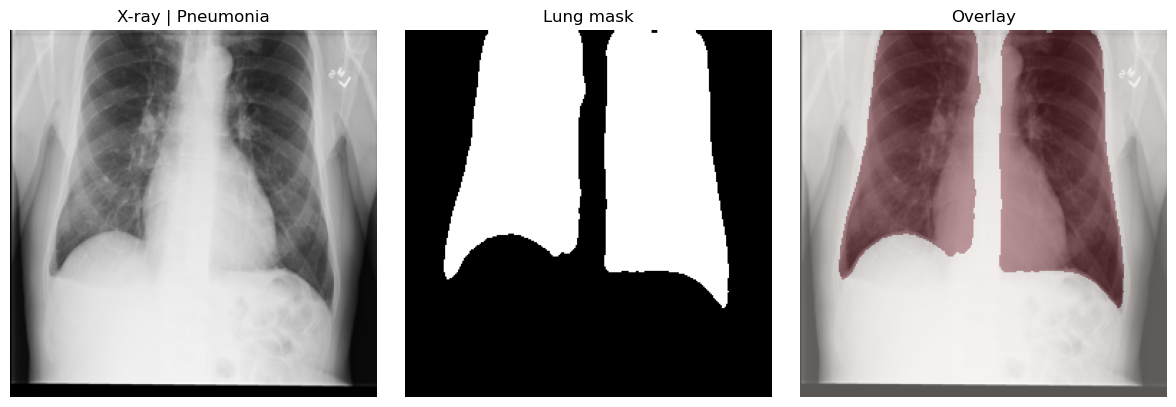

In [6]:
# Visualize one X-ray and its lung mask
sample_idx = 1
x, y, metadata = train_dataset[sample_idx]

xray = x[0].detach().cpu().numpy()
mask = x[1].detach().cpu().numpy() if x.shape[0] > 1 else None
label_name = ['Healthy', 'Pneumonia'][int(y.argmax().item())]

if mask is None:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(xray, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'X-ray | {label_name}')
    ax.axis('off')
else:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(xray, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'X-ray | {label_name}')

    axes[1].imshow(mask, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Lung mask')

    axes[2].imshow(xray, cmap='gray', vmin=0, vmax=1)
    axes[2].imshow(mask, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
    axes[2].set_title('Overlay')

    for ax in axes:
        ax.axis('off')

plt.tight_layout()


In [7]:
def undersample_healthy(dataset, healthy_to_pneumonia_ratio=1.0, seed=42):
    labels = dataset.labels

    # Labels are one-hot: [1, 0] = healthy, [0, 1] = pneumonia
    class_idx = labels.argmax(dim=1)

    healthy_idx = torch.where(class_idx == 0)[0]
    pneumonia_idx = torch.where(class_idx == 1)[0]

    n_pneumonia = len(pneumonia_idx)
    n_healthy_keep = int(healthy_to_pneumonia_ratio * n_pneumonia)
    n_healthy_keep = min(n_healthy_keep, len(healthy_idx))

    generator = torch.Generator().manual_seed(seed)
    perm = torch.randperm(len(healthy_idx), generator=generator)
    healthy_sampled_idx = healthy_idx[perm[:n_healthy_keep]]

    selected_idx = torch.cat([pneumonia_idx, healthy_sampled_idx])

    # Shuffle final selected set
    selected_idx = selected_idx[torch.randperm(len(selected_idx), generator=generator)]

    print(f"Pneumonia kept: {len(pneumonia_idx)}")
    print(f"Healthy kept: {len(healthy_sampled_idx)}")
    print(f"Final train size: {len(selected_idx)}")

    return Subset(dataset, selected_idx.tolist())

In [8]:
balanced_train_dataset = undersample_healthy(
    train_dataset,
    healthy_to_pneumonia_ratio=10.0,  # 1.0 means 1 healthy per 1 pneumonia
    seed=42
)

train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Pneumonia kept: 1014
Healthy kept: 10140
Final train size: 11154


### 4. Model, Loss, Optimizer

In [9]:
# def split_image_and_mask(x):
#     x_img = x[:, 0:1, :, :]
#     x_mask = x[:, 1:2, :, :].clamp(0, 1) if x.size(1) > 1 else None
#     return x_img, x_mask

# def mixed_reconstruction_loss(pred, target, weight=None):
#     loss_map = 0.5 * F.mse_loss(pred, target, reduction='none') + 0.5 * F.l1_loss(pred, target, reduction='none')
#     if weight is None:
#         return loss_map.mean()
#     return (loss_map * weight).sum() / weight.sum().clamp_min(1.0)

# def vae_loss(x, x_hat, mu, logvar, beta=1.0, lambda_lung=1.0, lambda_outside=2.0):
#     x_img, x_mask = split_image_and_mask(x)
#     reconstruction_loss = mixed_reconstruction_loss(x_hat, x_img)

#     if x_mask is None:
#         lung_loss = torch.zeros((), device=x.device)
#         outside_loss = torch.zeros((), device=x.device)
#     else:
#         lung_loss = mixed_reconstruction_loss(x_hat, x_img, x_mask)
#         outside_loss = mixed_reconstruction_loss(x_hat, x_img, 1.0 - x_mask)

#     # Normalize KLD by the batch size so it is on the same scale as the reconstruction loss.
#     KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
#     KLD = KLD / x.size(0)
#     total_loss = reconstruction_loss + lambda_lung * lung_loss + lambda_outside * outside_loss + beta * KLD
#     return total_loss, reconstruction_loss, lung_loss, outside_loss, KLD


In [10]:
def split_image_and_mask(x):
    x_img = x[:, 0:1, :, :]
    x_mask = x[:, 1:2, :, :].clamp(0, 1) if x.size(1) > 1 else None
    return x_img, x_mask

def reconstruction_loss(x, x_hat):
    mse = F.mse_loss(x_hat, x)
    l1 = F.l1_loss(x_hat, x)
    return 0.5 * mse + 0.5 * l1

# def masked_reconstruction_loss(x, x_hat, mask=None):
#     loss_map = 0.5 * F.mse_loss(x_hat, x, reduction='none') + 0.5 * F.l1_loss(x_hat, x, reduction='none')
#     if mask is None:
#         return loss_map.mean()
#     return (loss_map * mask).sum() / mask.sum().clamp_min(1.0)

def masked_l1_loss(x, y, mask):
    return (torch.abs(x - y) * mask).sum() / mask.sum().clamp_min(1.0)


def masked_ssim_loss(x, y, mask, window_size=7):
    padding = window_size // 2
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    mu_x = F.avg_pool2d(x, window_size, stride=1, padding=padding)
    mu_y = F.avg_pool2d(y, window_size, stride=1, padding=padding)
    sigma_x = F.avg_pool2d(x * x, window_size, stride=1, padding=padding) - mu_x.pow(2)
    sigma_y = F.avg_pool2d(y * y, window_size, stride=1, padding=padding) - mu_y.pow(2)
    sigma_xy = F.avg_pool2d(x * y, window_size, stride=1, padding=padding) - mu_x * mu_y

    ssim_map = ((2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)) / (
        (mu_x.pow(2) + mu_y.pow(2) + c1) * (sigma_x + sigma_y + c2)
    )
    loss_map = (1.0 - ssim_map).clamp(0, 2)
    return (loss_map * mask).sum() / mask.sum().clamp_min(1.0)


def masked_reconstruction_loss(x, y, mask, ssim_weight=0.5):
    l1 = masked_l1_loss(x, y, mask)
    ssim = masked_ssim_loss(x, y, mask)
    return (1.0 - ssim_weight) * l1 + ssim_weight * ssim

def lung_loss(x, x_hat, lung_mask):
    mse = F.mse_loss(
        x_hat * lung_mask,
        x * lung_mask
    )

    l1 = F.l1_loss(
        x_hat * lung_mask,
        x * lung_mask
    )

    return 0.5 * mse + 0.5 * l1

def outside_change_loss(x, x_hat, lung_mask):

    outside_mask = 1.0 - lung_mask

    change = torch.abs(x_hat - x)

    return (change * outside_mask).sum() / outside_mask.sum().clamp_min(1.0)

def kl_loss(mu, logvar):

    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    return kl.sum(dim=1).mean()

def validation_image_score(x, x_hat):
    x_img, x_mask = split_image_and_mask(x)
    outside_mask = 1.0 - x_mask
    inside_ssim = 1.0 - masked_ssim_loss(x_img, x_hat, x_mask)
    outside_ssim = 1.0 - masked_ssim_loss(x_img, x_hat, outside_mask)
    return 0.5 * inside_ssim + 0.5 * outside_ssim

def cvae_loss(x,
    x_hat,
    mu,
    logvar,
    beta=1.0,
    lambda_lung=2.0,
    lambda_outside=0.5
):
    x_img, x_mask = split_image_and_mask(x)
    outside_mask = 1.0 - x_mask if x_mask is not None else None
    rec = reconstruction_loss(x_img, x_hat)

    # lung = lung_loss(x_img, x_hat, x_mask)
    lung = masked_reconstruction_loss(x_img, x_hat, x_mask) if x_mask is not None else torch.zeros((), device=x.device)

    outside = masked_reconstruction_loss(x_img, x_hat, outside_mask) if outside_mask is not None else torch.zeros((), device=x.device)

    kl = kl_loss(mu, logvar)

    total_loss = (rec + lambda_lung * lung + lambda_outside * outside + beta * kl)

    return total_loss, rec, lung, outside, kl

In [11]:
model = CVAE(
    img_channels=img_channels,
    img_size=img_size,
    latent_dim=latent_dim,
    num_classes=num_classes,
    metadata_dim=metadata_dim,  # age + gender
    output_channels=1,
    base_channels=base_channels,
    dropout=dropout
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=lr)

### 5. Training

In [12]:
def evaluate(model, evaluate_loader, device, epoch, beta=1.0, lambda_lung=1.0, lambda_outside=2.0, results_dir="../training-results/cvae/results"):
    model.eval()
    total_loss = 0
    total_rec_loss = 0
    total_lung_loss = 0
    total_outside_loss = 0
    total_kld = 0
    total_image_score = 0
    with torch.no_grad():
        for i, batch in enumerate(evaluate_loader):
            x, y, m = batch
            x = x.to(device)
            y = y.to(device)
            m = m.to(device) if m is not None else None
            
            x_img, _ = split_image_and_mask(x)
            x_hat, mu, logvar = model(x, y, m)
            loss, rec_loss, lung_loss, outside_loss, kld = cvae_loss(
                x, x_hat, mu, logvar,
                beta=beta,
                lambda_lung=lambda_lung,
                lambda_outside=lambda_outside,
            )
            image_score = validation_image_score(x, x_hat)
            total_loss += loss.item() * x.size(0)
            total_rec_loss += rec_loss.item() * x.size(0)
            total_lung_loss += lung_loss.item() * x.size(0)
            total_outside_loss += outside_loss.item() * x.size(0)
            total_kld += kld.item() * x.size(0)
            total_image_score += image_score.item() * x.size(0)

            if i == 0:
                n = min(x.size(0), 8)
                comparison = torch.cat([x_img[:n], x_hat[:n]], dim=0)
                save_image(comparison.cpu(), f'{results_dir}/reconstruction_{epoch}.png', nrow=n)

    avg_loss = total_loss / len(evaluate_loader.dataset)
    avg_rec_loss = total_rec_loss / len(evaluate_loader.dataset)
    avg_lung_loss = total_lung_loss / len(evaluate_loader.dataset)
    avg_outside_loss = total_outside_loss / len(evaluate_loader.dataset)
    avg_kld = total_kld / len(evaluate_loader.dataset)
    avg_image_score = total_image_score / len(evaluate_loader.dataset)
    tqdm.write('Validation set loss (epoch {:03d}): total={:.3f}, rec={:.3f}, lung={:.3f}, outside={:.3f}, kld={:.3f}, image_score={:.3f}'.format(epoch, avg_loss, avg_rec_loss, avg_lung_loss, avg_outside_loss, avg_kld, avg_image_score))
    return avg_loss, avg_image_score


In [13]:
def train(model, train_loader, val_loader, optimizer, device, epoch, beta=1.0, lambda_lung=1.0, lambda_outside=2.0):
    """Train the CVAE model for a single epoch."""
    model.train()
    total_loss = 0
    total_rec_loss = 0
    total_lung_loss = 0
    total_outside_loss = 0
    total_kld = 0
    total_image_score = 0

    # Initialize tqdm (shows the progress during training)
    progress_bar = tqdm(train_loader, desc='Epoch {:03d}'.format(epoch), leave=False, disable=False)

    for x, y, m in progress_bar:
        x = x.to(device)
        y = y.to(device)
        m = m.to(device) if m is not None else None
        
        # Forward pass
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x, y, m)
        
        # Compute loss
        loss, rec_loss, lung_loss, outside_loss, kld = cvae_loss(
            x, x_hat, mu, logvar,
            beta=beta,
            lambda_lung=lambda_lung,
            lambda_outside=lambda_outside,
        )
        
        # Backward pass
        loss.backward()
        #Update model parameters
        optimizer.step()

        with torch.no_grad():
            image_score = validation_image_score(x, x_hat)
        
        # Track loss
        total_loss += loss.item() * x.size(0)
        total_rec_loss += rec_loss.item() * x.size(0)
        total_lung_loss += lung_loss.item() * x.size(0)
        total_outside_loss += outside_loss.item() * x.size(0)
        total_kld += kld.item() * x.size(0)
        total_image_score += image_score.item() * x.size(0)
        
        # Update the progress bar with the current batch's loss
        progress_bar.set_postfix({'loss': '{:.3f}'.format(loss.item()), 'lung': '{:.3f}'.format(lung_loss.item()), 'outside': '{:.3f}'.format(outside_loss.item()), 'image_score': '{:.3f}'.format(image_score.item())})
    
    avg_loss = total_loss / len(train_loader.dataset)
    avg_rec_loss = total_rec_loss / len(train_loader.dataset)
    avg_lung_loss = total_lung_loss / len(train_loader.dataset)
    avg_outside_loss = total_outside_loss / len(train_loader.dataset)
    avg_kld = total_kld / len(train_loader.dataset)
    avg_image_score = total_image_score / len(train_loader.dataset)
    tqdm.write('Training set loss (epoch {:03d}): total={:.3f}, rec={:.3f}, lung={:.3f}, outside={:.3f}, kld={:.3f}, image_score={:.3f}'.format(epoch, avg_loss, avg_rec_loss, avg_lung_loss, avg_outside_loss, avg_kld, avg_image_score))

    #Evaluate on validation set after each epoch
    val_loss, val_image_score = evaluate(model, val_loader, device, epoch, beta=beta, lambda_lung=lambda_lung, lambda_outside=lambda_outside)
    return avg_loss, val_loss, val_image_score


In [14]:
def save_checkpoint(model, optimizer, epoch, train_loss, val_loss, checkpoint_dir="../training-results/cvae/models"):
    """Save model checkpoint."""
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch:03d}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")
    return checkpoint_path

def load_checkpoint(model, optimizer, checkpoint_path):
    """Load model checkpoint."""
    if not os.path.exists(checkpoint_path):
        print(f"Checkpoint not found: {checkpoint_path}")
        return 0
    
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    print(f"Checkpoint loaded from epoch {epoch}: {checkpoint_path}")
    return epoch

def get_latest_checkpoint(checkpoint_dir="../training-results/cvae/models"):
    """Get the latest checkpoint path."""
    if not os.path.exists(checkpoint_dir):
        return None
    
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.startswith("checkpoint_epoch_")]
    if not checkpoints:
        return None
    
    checkpoints.sort()
    latest = checkpoints[-1]
    return os.path.join(checkpoint_dir, latest)

### 6. Training Loop

In [15]:
def beta_schedule(epoch, total_epochs, max_beta=1.0):
    # Ramp beta from a small positive value up to max_beta over the first half of training.
    return max_beta * min(1.0, (epoch + 1) / (total_epochs * 0.5))

In [16]:
def train_loop(model, train_loader, val_loader, optimizer, device, epochs=10, beta=0.2, lambda_lung=1.0, lambda_outside=2.0, checkpoint_dir="../training-results/cvae/models", resume=True, early_stopping_patience=None, early_stopping_min_delta=0.0):
    """Train the CVAE model for multiple epochs."""
    model.to(device)
    train_losses, val_losses, val_image_scores = [], [], []
    start_epoch = 0
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_checkpoint_path = None
    max_beta = beta
    best_image_score = -float('inf')

    # Load latest checkpoint if resume is True
    if resume:
        latest_checkpoint = get_latest_checkpoint(checkpoint_dir)
        if latest_checkpoint:
            start_epoch = load_checkpoint(model, optimizer, latest_checkpoint) + 1
    
    for epoch in range(start_epoch, epochs):
        current_beta = beta_schedule(epoch, epochs, max_beta=max_beta)
        avg_loss, val_loss, val_image_score = train(model, train_loader, val_loader, optimizer, device, epoch, beta=current_beta, lambda_lung=lambda_lung, lambda_outside=lambda_outside)
        train_losses.append(avg_loss)
        val_losses.append(val_loss)
        val_image_scores.append(val_image_score)
        
        # if val_loss < best_val_loss - early_stopping_min_delta:
        #     best_val_loss = val_loss
        #     epochs_without_improvement = 0
        #     best_checkpoint_path = save_checkpoint(model, optimizer, epoch, avg_loss, val_loss, checkpoint_dir)
        # else:
        #     epochs_without_improvement += 1

        score_window = val_image_scores[-early_stopping_smoothing:]
        smoothed_image_score = float(np.mean(score_window))
        can_stop = epoch + 1 >= early_stopping_warmup

        if smoothed_image_score > best_image_score + early_stopping_min_delta:
            best_image_score = smoothed_image_score
            epochs_without_improvement = 0
            best_checkpoint_path = save_checkpoint(model, optimizer, epoch, avg_loss, val_loss, checkpoint_dir)
        elif can_stop:
            epochs_without_improvement += 1

        if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
            tqdm.write(f'Early stopping at epoch {epoch:03d}. Best val loss: {best_val_loss:.3f}. Best checkpoint: {best_checkpoint_path}')
            break

        # Save periodic checkpoint
        if epoch % 10 == 0 or epoch == epochs - 1:  # Save every 10 epochs and the last epoch
            save_checkpoint(model, optimizer, epoch, avg_loss, val_loss, checkpoint_dir)
    
    if best_checkpoint_path is not None:
        checkpoint = torch.load(best_checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        tqdm.write(f'Restored best checkpoint: {best_checkpoint_path}')

    # Save the recorded training losses to a txt file
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    np.savetxt(f'{checkpoint_dir}/training_losses.txt', np.array(train_losses), delimiter='\n')
    # Save the recorded validation losses to a txt file
    np.savetxt(f'{checkpoint_dir}/validation_losses.txt', np.array(val_losses), delimiter='\n')
    # Save the recorded validation image scores to a txt file
    np.savetxt(f'{checkpoint_dir}/validation_image_scores.txt', np.array(val_image_scores), delimiter='\n')

    return train_losses, val_losses, val_image_scores


### 7. Generate Counterfactuals and Test

In [17]:
# def counterfactual_loss(x_img, x_cf, x_mask, mu, device, z, lambda_outside=2.0, lambda_sim=2.0, lambda_z=0.1):
#     # Keep the counterfactual close to the source image, especially outside the lungs.
#     recon_loss = reconstruction_loss(x_img, x_cf)
#     outside_loss = outside_change_loss(x_img, x_cf, x_mask) if x_mask is not None else torch.zeros((), device=device)
#     z_reg = F.mse_loss(z, mu, reduction='mean')
#     # Keeps the counterfactual close to the original image in latent space, preventing unrealistic changes
#     loss = lambda_sim * recon_loss + lambda_outside * outside_loss + lambda_z * z_reg
#     return loss

def counterfactual_loss(x, x_cf, mu, device, z, lambda_outside=2.0, lambda_sim=2.0, lambda_z=0.1):
    x_img, x_mask = split_image_and_mask(x)
    outside_mask = 1.0 - x_mask

    # rec_loss = reconstruction_loss(x_img, x_cf)
    rec_outside = masked_reconstruction_loss(x_img, x_cf, outside_mask) if outside_mask is not None else torch.zeros((), device=device)
    rec_inside = masked_reconstruction_loss(x_img, x_cf, x_mask) if x_mask is not None else torch.zeros((), device=device)
    z_reg = F.mse_loss(z, mu, reduction='mean')

    loss = (
        # lambda_sim * rec_loss +
        lambda_outside * rec_outside +
        0.1 * lambda_sim * rec_inside +
        lambda_z * z_reg
    )
    return loss

In [18]:
def generate_counterfactual(model, x, y_source, y_target, m=None,
                            num_steps=50, lr=1e-2, lambda_sim=2.0, lambda_outside=2.0, lambda_z=0.1):
    model.eval()

    with torch.no_grad():
        mu, logvar, skips = model.encode(x, y_source, m, return_skips=True)
        z_init = model.reparameterize(mu, logvar)

    z = z_init.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([z], lr=lr)
    # x_img, x_mask = split_image_and_mask(x)

    for _ in range(num_steps):
        x_cf = model.decode(z, y_target, m, skips=skips)
        loss = counterfactual_loss(x, x_cf, mu, x.device, z, lambda_outside=lambda_outside, lambda_sim=lambda_sim, lambda_z=lambda_z)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # After optimization, decode the final counterfactual
    x_cf = model.decode(z, y_target, m, skips=skips)
    return x_cf

def save_counterfactuals_individual(x_original, x_counterfactual, start_idx=0, 
                                    original_dir="../training-results/cvae/results/original/",
                                    counterfactual_dir="../training-results/cvae/results/counterfactuals/"):
    """Save original and counterfactual images individually and as pairs.
    
    Args:
        x_original: Original images (batch_size, 1, 128, 128)
        x_counterfactual: Counterfactual images (batch_size, 1, 128, 128)
        start_idx: Starting index for image naming
        original_dir: Directory to save original images
        counterfactual_dir: Directory to save counterfactual images
    """
    Path(original_dir).mkdir(parents=True, exist_ok=True)
    Path(counterfactual_dir).mkdir(parents=True, exist_ok=True)
    
    # Ensure tensors are in image format (batch_size, 1, 128, 128)
    if x_original.dim() == 4 and x_original.size(1) > 1:
        x_original = x_original[:, 0:1, :, :]
    if x_original.dim() == 2:
        x_original = x_original.view(-1, 1, 128, 128)
    if x_counterfactual.dim() == 2:
        x_counterfactual = x_counterfactual.view(-1, 1, 128, 128)
    
    batch_size = x_original.size(0)
    
    # Save each image individually
    for i in range(batch_size):
        img_idx = start_idx + i
        
        # Save original image
        orig_img = x_original[i:i+1]
        orig_path = os.path.join(original_dir, f"img_{img_idx:06d}_original.png")
        save_image(orig_img, orig_path)
        
        # Save counterfactual image
        cf_img = x_counterfactual[i:i+1]
        cf_path = os.path.join(counterfactual_dir, f"img_{img_idx:06d}_counterfactual.png")
        save_image(cf_img, cf_path)
        
        # Save pair (original and counterfactual side by side)
        pair = torch.cat([orig_img, cf_img], dim=0)
        pair_path = os.path.join(counterfactual_dir, f"img_{img_idx:06d}_pair.png")
        save_image(pair, pair_path, nrow=2)
    
    print(f"Saved {batch_size} original images to {original_dir}")
    print(f"Saved {batch_size} counterfactual images and pairs to {counterfactual_dir}")


In [19]:
def test(test_loader, model, device):
    image_idx = 0
    for batch_idx, (x, y, m) in enumerate(test_loader):
        x = x.to(device)
        y = y.to(device)
        m = m.to(device)

        # Generate counterfactuals (flip class: 0->1, 1->0)
        y_target = 1 - y  # Flip labels: healthy (0) -> pneumonia (1), or vice versa

        x_cf = generate_counterfactual(model, x, y, y_target, m, lambda_outside=lambda_outside)

        # Save original and counterfactual images individually and as pairs
        save_counterfactuals_individual(
            x[:, 0:1, :, :].cpu(), 
            x_cf.cpu(), 
            start_idx=image_idx,
            original_dir="../training-results/cvae/results/original/",
            counterfactual_dir="../training-results/cvae/results/counterfactuals/"
        )
        
        image_idx += x.size(0)
        print(f"Batch {batch_idx + 1} completed. Total images processed: {image_idx}")
    
    print(f"\nCounterfactual generation complete! Processed {image_idx} test images.")

### 8. Training the model

In [20]:
train_losses, val_losses, val_image_scores = train_loop(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=epochs,
    beta=beta,
    lambda_lung=lambda_lung,
    lambda_outside=lambda_outside,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    checkpoint_dir=checkpoint_dir,
    resume=False,
)

Training set loss (epoch 000): total=0.572, rec=0.026, lung=0.182, outside=0.120, kld=142.639, image_score=0.746
Validation set loss (epoch 000): total=0.230, rec=0.012, lung=0.060, outside=0.051, kld=100.651, image_score=0.910
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_000.pt
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_000.pt


Training set loss (epoch 001): total=0.208, rec=0.011, lung=0.050, outside=0.048, kld=59.612, image_score=0.924
Validation set loss (epoch 001): total=0.137, rec=0.008, lung=0.034, outside=0.031, kld=44.375, image_score=0.951
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_001.pt


Training set loss (epoch 002): total=0.146, rec=0.009, lung=0.034, outside=0.033, kld=34.742, image_score=0.950
Validation set loss (epoch 002): total=0.113, rec=0.008, lung=0.027, outside=0.025, kld=29.506, image_score=0.964
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_002.pt


Training set loss (epoch 003): total=0.116, rec=0.008, lung=0.026, outside=0.026, kld=23.731, image_score=0.962
Validation set loss (epoch 003): total=0.083, rec=0.006, lung=0.021, outside=0.018, kld=19.729, image_score=0.972
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_003.pt


KeyboardInterrupt: 

In [ ]:
# train_losses = np.loadtxt("../training-results/cvae/models/training_losses.txt")
# val_losses = np.loadtxt("../training-results/cvae/models/validation_losses.txt")
# val_image_scores = np.loadtxt("../training-results/cvae/models/validation_image_scores.txt")

### 9. Training Curves

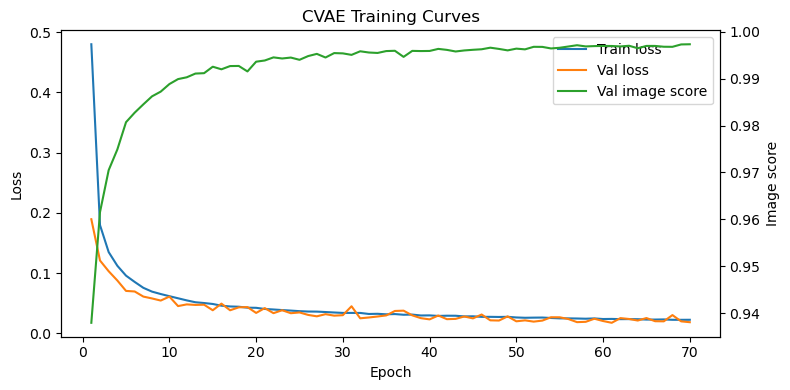

In [22]:
num_completed_epochs = min(len(train_losses), len(val_losses))
num_epochs = range(1, num_completed_epochs + 1)

if num_completed_epochs == 0:
    raise ValueError("No training history available to plot. Run train_loop with resume=False or load saved losses first.")

fig, ax_loss = plt.subplots(figsize=(8, 4))
ax_loss.plot(num_epochs, train_losses[:num_completed_epochs], label="Train loss")
ax_loss.plot(num_epochs, val_losses[:num_completed_epochs], label="Val loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")

if 'val_image_scores' in globals() and len(val_image_scores) >= num_completed_epochs:
    ax_score = ax_loss.twinx()
    ax_score.plot(num_epochs, val_image_scores[:num_completed_epochs], color="tab:green", label="Val image score")
    ax_score.set_ylabel("Image score")
    lines, labels = ax_loss.get_legend_handles_labels()
    score_lines, score_labels = ax_score.get_legend_handles_labels()
    ax_loss.legend(lines + score_lines, labels + score_labels, loc="best")
else:
    ax_loss.legend(loc="best")

plt.title("CVAE Training Curves")

plt.tight_layout()
plt.show()

### 10. Generate Counterfactuals

In [23]:
test(test_loader, model, device)

Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 1 completed. Total images processed: 16
Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 2 completed. Total images processed: 32
Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 3 completed. Total images processed: 48
Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 4 completed. Total images processed: 64
Saved 16 original images to ../training-results/cvae/results/original/
Saved 16 counterfactual images and pairs to ../training-results/cvae/results/counterf

### 10.1 Identify Original and Counterfactual Labels


In [ ]:
import pandas as pd

LABEL_NAMES = {0: "healthy", 1: "pneumonia"}

def label_tensor_to_class_index(label):
    """Return class index from a scalar or one-hot label tensor."""
    label = torch.as_tensor(label).detach().cpu()
    if label.ndim == 0 or label.numel() == 1:
        return int(label.item())
    return int(torch.argmax(label).item())

def identify_counterfactual_labels(test_dataset, results_dir=project_root / "training-results" / "cvae" / "results"):
    """Map saved original/counterfactual images to labels from test_dataset.

    Original labels come directly from test_dataset. Counterfactual labels are the
    flipped target labels used in test(): healthy <-> pneumonia.
    """
    # if results_dir is None:
    #     results_dir = project_root / "training-results" / "cvae" / "results"

    results_dir = Path(results_dir)
    original_dir = results_dir / "original"
    counterfactual_dir = results_dir / "counterfactuals"

    rows = []
    for image_idx, label in enumerate(test_dataset.labels):
        original_class = label_tensor_to_class_index(label)
        counterfactual_class = 1 - original_class

        rows.append({
            "image_index": f"{image_idx:06d}",
            "original_image": str(original_dir / f"img_{image_idx:06d}_original.png"),
            "original_label_id": original_class,
            "original_label": LABEL_NAMES[original_class],
            "counterfactual_image": str(counterfactual_dir / f"img_{image_idx:06d}_counterfactual.png"),
            "counterfactual_label_id": counterfactual_class,
            "counterfactual_label": LABEL_NAMES[counterfactual_class],
        })

    labels_df = pd.DataFrame(rows)
    output_csv = results_dir / "counterfactual_labels.csv"
    labels_df.to_csv(output_csv, index=False)

    print(f"Saved labels for {len(labels_df)} original/counterfactual pairs to: {output_csv}")
    print("\nOriginal image label counts:")
    print(labels_df["original_label"].value_counts().to_string())
    print("\nCounterfactual image label counts:")
    print(labels_df["counterfactual_label"].value_counts().to_string())

    return labels_df

labels_df = identify_counterfactual_labels(test_dataset)

Saved labels for 9176 original/counterfactual pairs to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_labels.csv

Original image label counts:
original_label
healthy      8978
pneumonia     198

Counterfactual image label counts:
counterfactual_label
pneumonia    8978
healthy       198


In [24]:
heatmap_paths = save_cvae_change_heatmap_sweep(test_dataset, max_batches=3)

print(f"Saved {len(heatmap_paths)} heatmap files.")
print(f"First heatmap: {heatmap_paths[0]}")

Saving CVAE change heatmaps:   0%|          | 3/4489 [00:02<52:16,  1.43it/s]

Saved 3 CVAE change heatmap PNGs to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\change_heatmaps
Reused samples to fill fixed-size rows: 0 healthy, 8780 pneumonia
Saved 3 heatmap files.
First heatmap: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\change_heatmaps\cvae_change_heatmap_001.png


### 11. Evaluate

In [25]:
DEFAULT_RESULTS_DIR = project_root / "training-results" / "cvae" / "results"

In [26]:
original_dir = DEFAULT_RESULTS_DIR / "original"
counterfactual_dir = DEFAULT_RESULTS_DIR / "counterfactuals"
output_json = DEFAULT_RESULTS_DIR / "counterfactual_metrics.json"
output_csv = DEFAULT_RESULTS_DIR / "counterfactual_ssim.csv"
batch_size = 32
num_workers = 0
device = "cuda" if torch.cuda.is_available() else "cpu"
allow_download = False

In [27]:
ssim_mean, ssim_std, ssim_min, ssim_max, ssim_rows = ssim_metric_calculation(device, output_csv, original_dir, counterfactual_dir)
fid, num_counterfactual_images, num_reference_images = fid_metric_calculation(original_dir, counterfactual_dir, device, batch_size, num_workers)

result = EvaluationResult(
    num_ssim_pairs=len(ssim_rows),
    ssim_mean=ssim_mean,
    ssim_std=ssim_std,
    ssim_min=ssim_min,
    ssim_max=ssim_max,
    num_counterfactual_images=num_counterfactual_images,
    num_reference_images=num_reference_images,
    fid=fid,
)
write_metrics_json(result, output_json)

print(json.dumps(asdict(result), indent=2))
print(f"\nSaved aggregate metrics to: {output_json}")
print(f"Saved per-image SSIM scores to: {output_csv}")

{
  "num_ssim_pairs": 9176,
  "ssim_mean": 0.9947625512830465,
  "ssim_std": 0.0027113136218277463,
  "ssim_min": 0.8923580646514893,
  "ssim_max": 0.9973961710929871,
  "num_counterfactual_images": 9176,
  "num_reference_images": 9176,
  "fid": 2.637024402618408
}

Saved aggregate metrics to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_metrics.json
Saved per-image SSIM scores to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_ssim.csv
